In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor




import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
train=pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
test=pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [3]:
train.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [4]:
train.info
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [5]:
train.shape

(517754, 14)

In [6]:
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [7]:
cat_cols = ['road_type','lighting','weather','time_of_day']
le=LabelEncoder()

for col in cat_cols:
    train[col] = le.fit_transform(train[col])

In [8]:
train.head(3)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,2,2,0.06,35,0,2,False,True,0,False,True,1,0.13
1,1,2,4,0.99,35,0,0,True,False,1,True,True,0,0.35
2,2,1,4,0.63,70,1,0,False,True,2,True,False,2,0.30


In [9]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']
for col in bool_cols:
    train[col]= train[col].astype(int)

In [10]:
train = train.drop(columns=['id'])

We deleted the id column because machine learning tries to assign meaning to every number.
Looking at the id column, one might think, "Oh, so the higher the id, the higher the risk!"
But this would be a false correlation because id is completely random.

In [11]:
x = train.drop(columns=['accident_risk'])
y = train['accident_risk'] 

In [12]:
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [14]:
y_pred = lr.predict(x_val)


In [15]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rmse


0.08844395424842222

In [16]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_val)



We create the model and set some parameters:

n_estimators = 200 It will create 200 trees. More → generally better, but slower.
max_depth = None Tree depth is unlimited → Trees will branch as much as they need data.
random_state = 42 We set the random numbers fixed → it will give the same result every time it's run.
n_jobs = -1 Uses all the computer's processors → runs faster.

In [17]:
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rmse_rf

0.05940224618610835

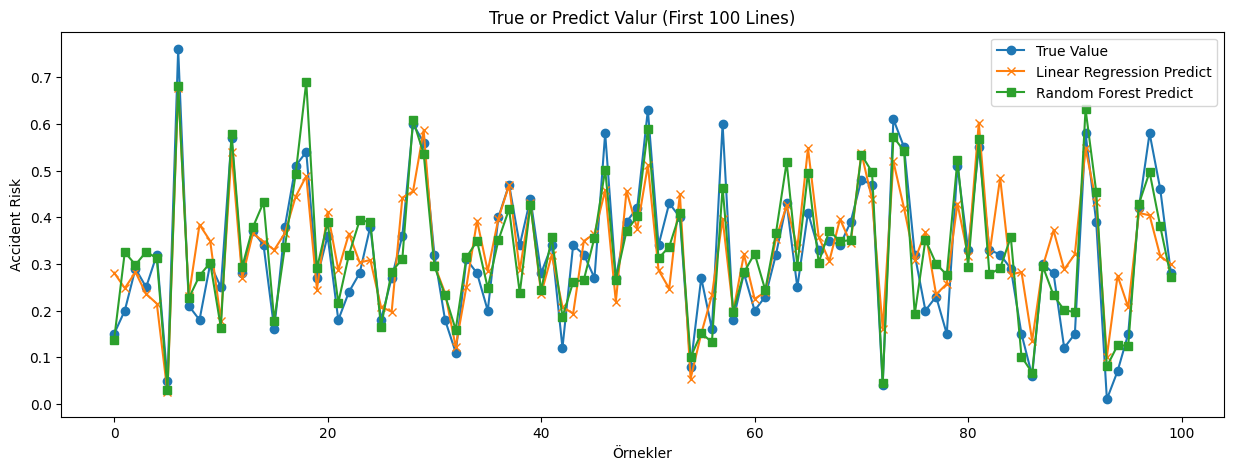

In [18]:
n_plot = 100
y_val_plot = y_val.iloc[:n_plot]
y_pred_lr_plot = lr.predict(x_val.iloc[:n_plot])
y_pred_rf_plot = rf.predict(x_val.iloc[:n_plot])

plt.figure(figsize=(15,5))

plt.plot(y_val_plot.values, label='True Value', marker='o')
plt.plot(y_pred_lr_plot, label='Linear Regression Predict', marker='x')
plt.plot(y_pred_rf_plot, label='Random Forest Predict', marker='s')

plt.title('True or Predict Valur (First 100 Lines)')
plt.xlabel('Örnekler')
plt.ylabel('Accident Risk')
plt.legend()
plt.show()
